# ASL Recognition with CNNs

This notebook implements a Convolutional Neural Network (CNN) for recognizing American Sign Language (ASL) gestures. We will compare the performance of a Fully Connected Neural Network (FCNN) with that of a CNN on the ASL dataset.

For more information on the ASL alphabet, you can refer to this site: https://www.asl.gs/

In [1]:
import random

import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

False

In [3]:
from pathlib import Path

base_path = Path.cwd()
candidate_paths = [
    base_path / "data" / "asl_data",
    base_path.parent / "data" / "asl_data",
]

data_base_path = next((p for p in candidate_paths if p.exists()), None)
if data_base_path is None:
    raise FileNotFoundError(
        "No se encontro la carpeta 'data/asl_data'. Verifica la estructura del proyecto."
    )

data_base_path = data_base_path.resolve()
path = str(data_base_path)
print(f"Ruta de datos: {path}")

Ruta de datos: C:\Users\fiona\OneDrive\Documentos\8vo\Inteligencia Computacional\ICO\data\asl_data


### Load data

The data for the ASL dataset is stored in CSV files. It is already split into training, validation, and test sets. Each row in the CSV files contains pixel values for a 28x28 image (flattened into a single row) and a label indicating the ASL gesture.

The labels are integers from 0 to 23, corresponding to the letters A-Z (J and Z are excluded because they require movement).

The images are grayscale, so each pixel value ranges from 0 to 255.

In [4]:
train_df = pd.read_csv(f"{path}/train.csv")
val_df = pd.read_csv(f"{path}/val.csv")
test_df = pd.read_csv(f"{path}/test.csv")
print(train_df.shape, val_df.shape, test_df.shape)

(27455, 785) (3586, 785) (3586, 785)


In [5]:
def label_to_letter(lbl):
    letter_code = ord('A') + int(lbl)
    return chr(letter_code) if letter_code < ord('J') else chr(letter_code + 1)

def show(img, lbl):
    i = img.reshape(28,28)
    plt.figure(figsize=(5,5))
    plt.title(label_to_letter(lbl), fontdict={'fontsize': 30})
    plt.axis('off')
    plt.imshow(i, cmap='gray')

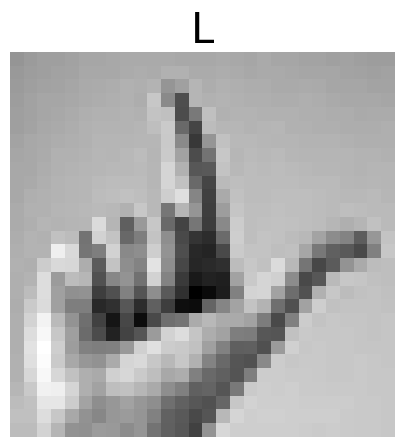

In [6]:
rnd_idx = random.choice(train_df.index)
image = train_df.iloc[rnd_idx].drop('label').values
label = train_df.iloc[rnd_idx]['label']
show(image, label)

## Preparing dataset

Let's start by creating the custom Dataset class for our ASL data. This class will take a DataFrame as input and will return the image and label for each sample. We will also normalize the pixel values to be between 0 and 1. The images will be reshaped as a 28x28 tensor with a single channel (grayscale).

In [7]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1

class AslDataset(Dataset):
    def __init__(self, base_df):
        x_df = base_df.copy()
        y_df = x_df.pop('label')
        x_df = x_df.values / 255
        x_df = x_df.reshape(-1, IMG_CHANNELS, IMG_WIDTH, IMG_HEIGHT)
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).long().to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

In [8]:
train_data = AslDataset(train_df)
val_data = AslDataset(val_df)
test_data = AslDataset(test_df)

In [9]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

## Training functions

Now we can define our training functions. Since we will use accuracy to evaluate our model, we will create a function to calculate accuracy as well. 

In [10]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

Our train function performs the full training loop. For each epoch, it computes the training loss and accuracy, and then evaluates the model on the validation set. It returns the history of training and validation losses and accuracies for plotting later.

In [11]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

This test function will evaluate the model on the test set after training is complete. It will calculate the average loss and accuracy across the entire test set.

In [12]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

## Training the models

### Baseline model - fully connected network

Before we implement the CNN, let's train a simple fully connected neural network (FCNN) as a baseline. This will help us understand the performance improvement that the CNN architecture provides for image data.

In [13]:
model_fcnn = nn.Sequential(
    nn.Flatten(),
    nn.Linear(IMG_HEIGHT * IMG_WIDTH, 512),
    nn.ReLU(),
    nn.Dropout(.3),

    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_fcnn = model_fcnn.to(device)

In [14]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_fcnn.parameters())

fcnn_res = train(model_fcnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [02:17<00:00,  6.85s/epoch, train_acc=0.8744, train_loss=0.3577, val_acc=0.6944, val_loss=1.0674]


In [15]:
fcnn_test_loss, fcnn_test_acc = test(model_fcnn, test_loader, loss_function)

### CNN model

Now let's implement a simple CNN architecture. We will use three convolutional layers followed by max pooling, and then a couple of fully connected layers before the output layer.

In [16]:
model_cnn = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),  # 25 x 28 x 28
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 25 x 14 x 14

    nn.Conv2d(25, 50, 3, stride=1, padding=1),  # 50 x 14 x 14
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # 50 x 7 x 7

    nn.Conv2d(50, 75, 3, stride=1, padding=1),  # 75 x 7 x 7
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_cnn = model_cnn.to(device)

In [17]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train(model_cnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [08:17<00:00, 24.86s/epoch, train_acc=0.9966, train_loss=0.0101, val_acc=0.9598, val_loss=0.2828]


In [18]:
cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

## Reflection section

### Which model is better at classifying ASL images?

The CNN model performed better, reaching about 95% accuracy.

### Which model was _faster_ to train?

The FCNN model was much faster than the CNN.

### Plot and compare the learning curves of both models. What do you observe about their training and validation performance over epochs?

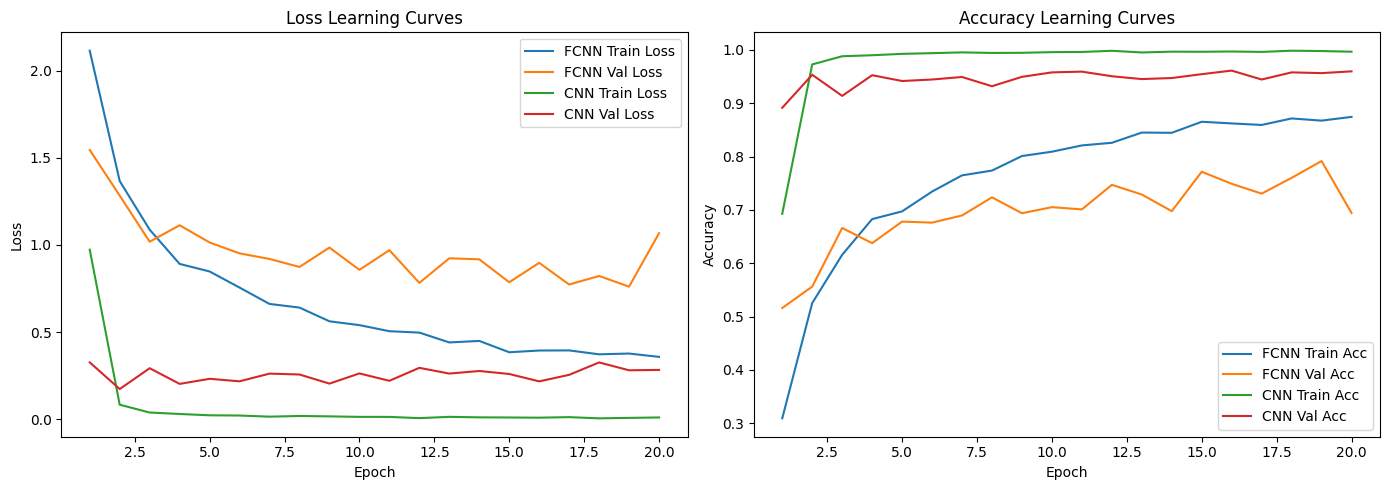

In [19]:
import matplotlib.pyplot as plt

def plot_learning_curves(fcnn_res, cnn_res):
    epochs = range(1, len(fcnn_res['train_loss']) + 1)

    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    axs[0].plot(epochs, fcnn_res['train_loss'], label='FCNN Train Loss')
    axs[0].plot(epochs, fcnn_res['val_loss'], label='FCNN Val Loss')
    axs[0].plot(epochs, cnn_res['train_loss'], label='CNN Train Loss')
    axs[0].plot(epochs, cnn_res['val_loss'], label='CNN Val Loss')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Loss')
    axs[0].set_title('Loss Learning Curves')
    axs[0].legend()

    axs[1].plot(epochs, fcnn_res['train_acc'], label='FCNN Train Acc')
    axs[1].plot(epochs, fcnn_res['val_acc'], label='FCNN Val Acc')
    axs[1].plot(epochs, cnn_res['train_acc'], label='CNN Train Acc')
    axs[1].plot(epochs, cnn_res['val_acc'], label='CNN Val Acc')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy')
    axs[1].set_title('Accuracy Learning Curves')
    axs[1].legend()

    plt.tight_layout()
    plt.show()

plot_learning_curves(fcnn_res, cnn_res)

The learning curves show that the CNN performs much better. Its loss drops quickly and stays low, and its accuracy gets very high. In contrast, the FCNN struggles more, with higher validation loss and lower accuracy, so the CNN learns the patterns more effectively.

### How many trainable parameters does each model have?

Remember that each convolutional layer has $K \times (C_{in} \times k_h \times k_w + 1)$ parameters, where $K$ is the number of filters, $C_{in}$ is the number of input channels, $k_h$ and $k_w$ are the kernel height and width, and the +1 accounts for the bias term.

Each fully connected layer has $N_{in} \times N_{out} + N_{out}$ parameters, where $N_{in}$ is the number of input features and $N_{out}$ is the number of output features.

In [20]:
def count_parameters(model, name):
    total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name}: {total:,}")

count_parameters(model_fcnn, "FCNN")
count_parameters(model_cnn, "CNN")

FCNN: 676,888
CNN: 403,799


Notably, the CNN actually uses fewer parameters than the FCNN while still achieving much better performance. This happens because convolutional layers share weights across the whole image using filters, instead of having to learn a separate weight for every connection between pixels and neurons, like fully connected layers do

### How do the models compare in terms of overfitting? Why do you think that is the case?

The FCNN shows more signs of overfitting. Its training accuracy is noticeably higher than its validation accuracy, creating a gap between the two.The CNN also overfits a little, but the difference between its training and validation performance is much smaller. Overall,the CNN doesn’t overfit as much, and it still performs really well on validation. It handles overfitting better in part because of how convolutions work since they share weights. And also, it uses dropout in a couple of places and has fewer total parameters, which also helps keep overfitting under control.

### Final conclusions and remarks

In conclusion, the CNN is the better option for this ASL image classification task. It reaches much higher accuracy, overfits less even though its training accuracy is higher, and it does all of this using fewer parameters. The only bad things is the training time,since the CNN takes longer per epoch. This activity shows why CNNs are commonly used for image tasks,they can capture patterns and relationships within the image, giving them a clear advantage over models that treat pixels as independent features.